In [ ]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("games.csv")

print(df.head())
print(df.columns)

         id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   
2  mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate  white   
3  kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate  white   
4  9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate  white   

  increment_code       white_id  white_rating      black_id  black_rating  \
0           15+2       bourgris          1500          a-00          1191   
1           5+10           a-00          1322     skinnerua          1261   
2           5+10         ischia          1496          a-00          1500   
3           20+0  daniamurashov          1439  adivanov2009          1454   
4           30+3      nik221107          1523  adivanov2009          1469   

                                               moves opening_e

In [ ]:
print("Shape:", df.shape)
print(df.describe())
print(df.isnull().sum())

Shape: (20058, 16)
         created_at  last_move_at         turns  white_rating  black_rating  \
count  2.005800e+04  2.005800e+04  20058.000000  20058.000000  20058.000000   
mean   1.483617e+12  1.483618e+12     60.465999   1596.631868   1588.831987   
std    2.850151e+10  2.850140e+10     33.570585    291.253376    291.036126   
min    1.376772e+12  1.376772e+12      1.000000    784.000000    789.000000   
25%    1.477548e+12  1.477548e+12     37.000000   1398.000000   1391.000000   
50%    1.496010e+12  1.496010e+12     55.000000   1567.000000   1562.000000   
75%    1.503170e+12  1.503170e+12     79.000000   1793.000000   1784.000000   
max    1.504493e+12  1.504494e+12    349.000000   2700.000000   2723.000000   

        opening_ply  
count  20058.000000  
mean       4.816981  
std        2.797152  
min        1.000000  
25%        3.000000  
50%        4.000000  
75%        6.000000  
max       28.000000  
id                0
rated             0
created_at        0
last_move_a

In [ ]:
df = df[['rated', 'turns', 'victory_status', 'winner',
         'white_rating', 'black_rating', 'opening_ply']]

df['rated'] = df['rated'].astype(int)

df = df.drop('victory_status', axis=1)

df['winner'] = df['winner'].map({'white': 0, 'black': 1, 'draw': 2})

df = df.dropna()

In [ ]:
print(df['winner'].value_counts())
print(df['winner'].value_counts(normalize=True))

winner
0    10001
1     9107
2      950
Name: count, dtype: int64
winner
0    0.498604
1    0.454033
2    0.047363
Name: proportion, dtype: float64


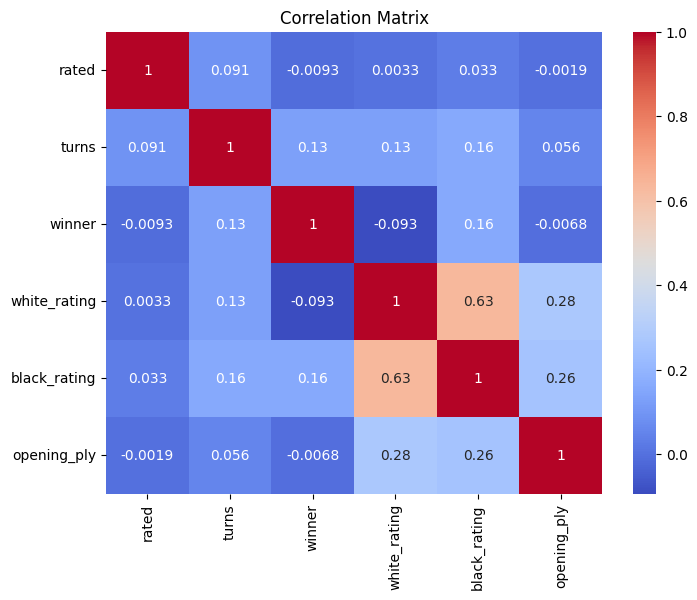

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X = df.drop('winner', axis=1)
y = df['winner']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

X_train, X_test, y_train, y_test

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression - Kavy Khanna

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'class_weight': ['balanced', None]
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=3000), param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)

model = grid_lr.best_estimator_

print("Best Logistic Params:", grid_lr.best_params_)

Best Logistic Params: {'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
print("Feature Importance (Logistic):")
for i, col in enumerate(X.columns):
    print(col, model.coef_[0][i])

Feature Importance (Logistic):
rated 0.08576061339284238
turns -0.2372438473072975
white_rating 0.49641421355992904
black_rating -0.5630995105376247
opening_ply 0.012895593861934295


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.6278664007976071
Precision: 0.6449807111285171
Recall: 0.6278664007976071
F1 Score: 0.611063122119325



Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.73      0.68      2004
           1       0.62      0.59      0.60      1816
           2       1.00      0.01      0.01       192

    accuracy                           0.63      4012
   macro avg       0.75      0.44      0.43      4012
weighted avg       0.64      0.63      0.61      4012



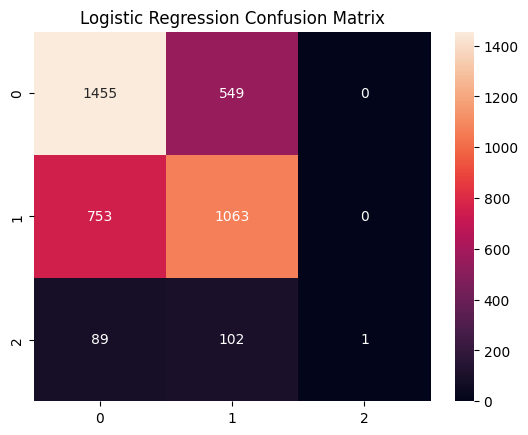

In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Decision Tree - Abhishek Bora

In [ ]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)

model_dt = grid_dt.best_estimator_

print("Best DT Params:", grid_dt.best_params_)

Best DT Params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [ ]:
importance = model_dt.feature_importances_
for i, col in enumerate(X.columns):
    print(col, importance[i])

rated 0.014381014955477885
turns 0.40483257749090296
white_rating 0.25927353410779547
black_rating 0.2424903969046496
opening_ply 0.07902247654117414


In [ ]:
y_pred_dt = model_dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_dt, average='weighted'))

Accuracy: 0.6699900299102692
Precision: 0.6564862730485791
Recall: 0.6699900299102692
F1 Score: 0.6614294532271101



Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.74      0.71      2004
           1       0.67      0.66      0.66      1816
           2       0.22      0.09      0.13       192

    accuracy                           0.67      4012
   macro avg       0.52      0.49      0.50      4012
weighted avg       0.66      0.67      0.66      4012



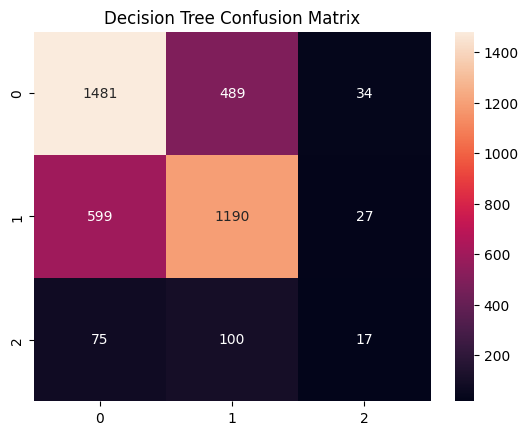

In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

SVM (Support Vector Machine) - Aditya Choudhary

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced', None]
}
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=3)

In [ ]:
grid_svm.fit(X_train, y_train)

model_svm = grid_svm.best_estimator_

print("Best SVM Parameters:", grid_svm.best_params_)

Best SVM Parameters: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}


In [23]:
model = grid_lr.best_estimator_
model_dt = grid_dt.best_estimator_
model_svm = grid_svm.best_estimator_

In [24]:
y_pred_svm = model_svm.predict(X_test)

In [25]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_svm, average='weighted'))

Accuracy : 0.6256231306081754
Precision: 0.5960511633029031
Recall   : 0.6256231306081754
F1 Score : 0.6066923403641223


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))


Classification Report:

              precision    recall  f1-score   support

           0       0.62      0.75      0.68      2004
           1       0.63      0.55      0.59      1816
           2       0.00      0.00      0.00       192

    accuracy                           0.63      4012
   macro avg       0.42      0.43      0.42      4012
weighted avg       0.60      0.63      0.61      4012



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


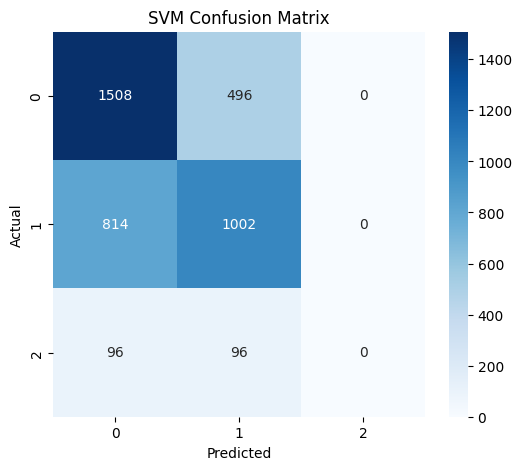

In [27]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
y_pred = model.predict(X_test)
y_pred_dt = model_dt.predict(X_test)
y_pred_svm = model_svm.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

print("Logistic:", accuracy_score(y_test, y_pred))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Logistic: 0.6278664007976071
Decision Tree: 0.6699900299102692
SVM: 0.6256231306081754


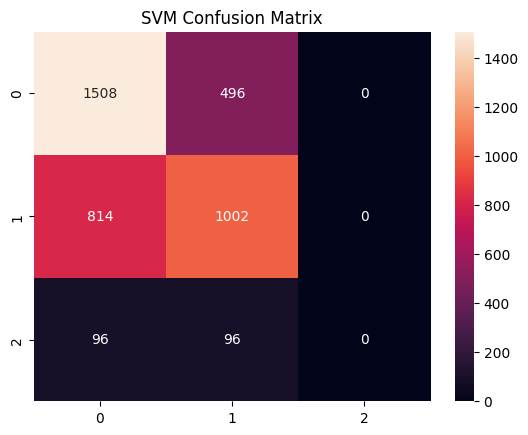

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.show()

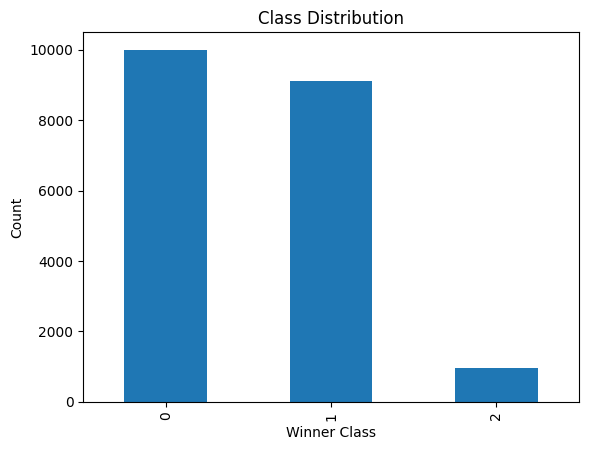

In [32]:
df['winner'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Winner Class")
plt.ylabel("Count")
plt.show()

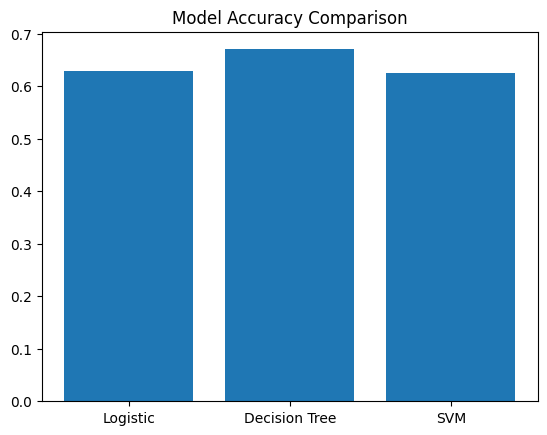

In [31]:
models = ['Logistic', 'Decision Tree', 'SVM']
accuracy = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_svm)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.show()

In [33]:
acc_lr = accuracy_score(y_test, y_pred)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("\nFinal Accuracy Comparison")
print("Logistic Regression:", acc_lr)
print("Decision Tree:", acc_dt)
print("SVM:", acc_svm)

best = max(acc_lr, acc_dt, acc_svm)

if best == acc_lr:
    print("\nBest Model: Logistic Regression")
elif best == acc_dt:
    print("\nBest Model: Decision Tree")
else:
    print("\nBest Model: SVM")


Final Accuracy Comparison
Logistic Regression: 0.6278664007976071
Decision Tree: 0.6699900299102692
SVM: 0.6256231306081754

Best Model: Decision Tree
